# Batch 2: water stress diagnosis
> Which plant was water stressed after 5 October? A blind diagnosis from the logs

Batch 2 is the SD-card dump collected on 9 October. It contains all of batch 1, from 23 September, plus the period from 5 October at about 17:00 to 9 October at 11:00. In that new period, the team water-stressed one of the four plants without saying which. This notebook tries to find it from the data. Batch 1 days serve as each plant's baseline.

The thermal signals use the unmasked leaf temperature. The variance masks are not reliable yet. 9 October has data only until 11:00, so daily statistics stop at 8 October.

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from speaking_plants.clean import *
from speaking_plants.leaf import *
from speaking_plants.logbook import *

In [ ]:
#| eval: false
mdf = share_ruuvi(measurements(clean(read_logs(sorted(Path('../../../data/b02').glob('dados_*.csv'))))))
us = leaf_series(mdf, no_masks(full_days(mdf, min_n=13)))
start_new = pd.Timestamp('2026-10-05 17:00')

## Leaf temperature relative to the other plants

All plants share the greenhouse climate. `peers` gives the mean of the other three plants. Subtracting it from each plant's smoothed leaf temperature removes the shared climate, and needs no air sensor. A plant that transpires less warms relative to the others, most at midday and in the afternoon. The dashed line marks the start of the new period:

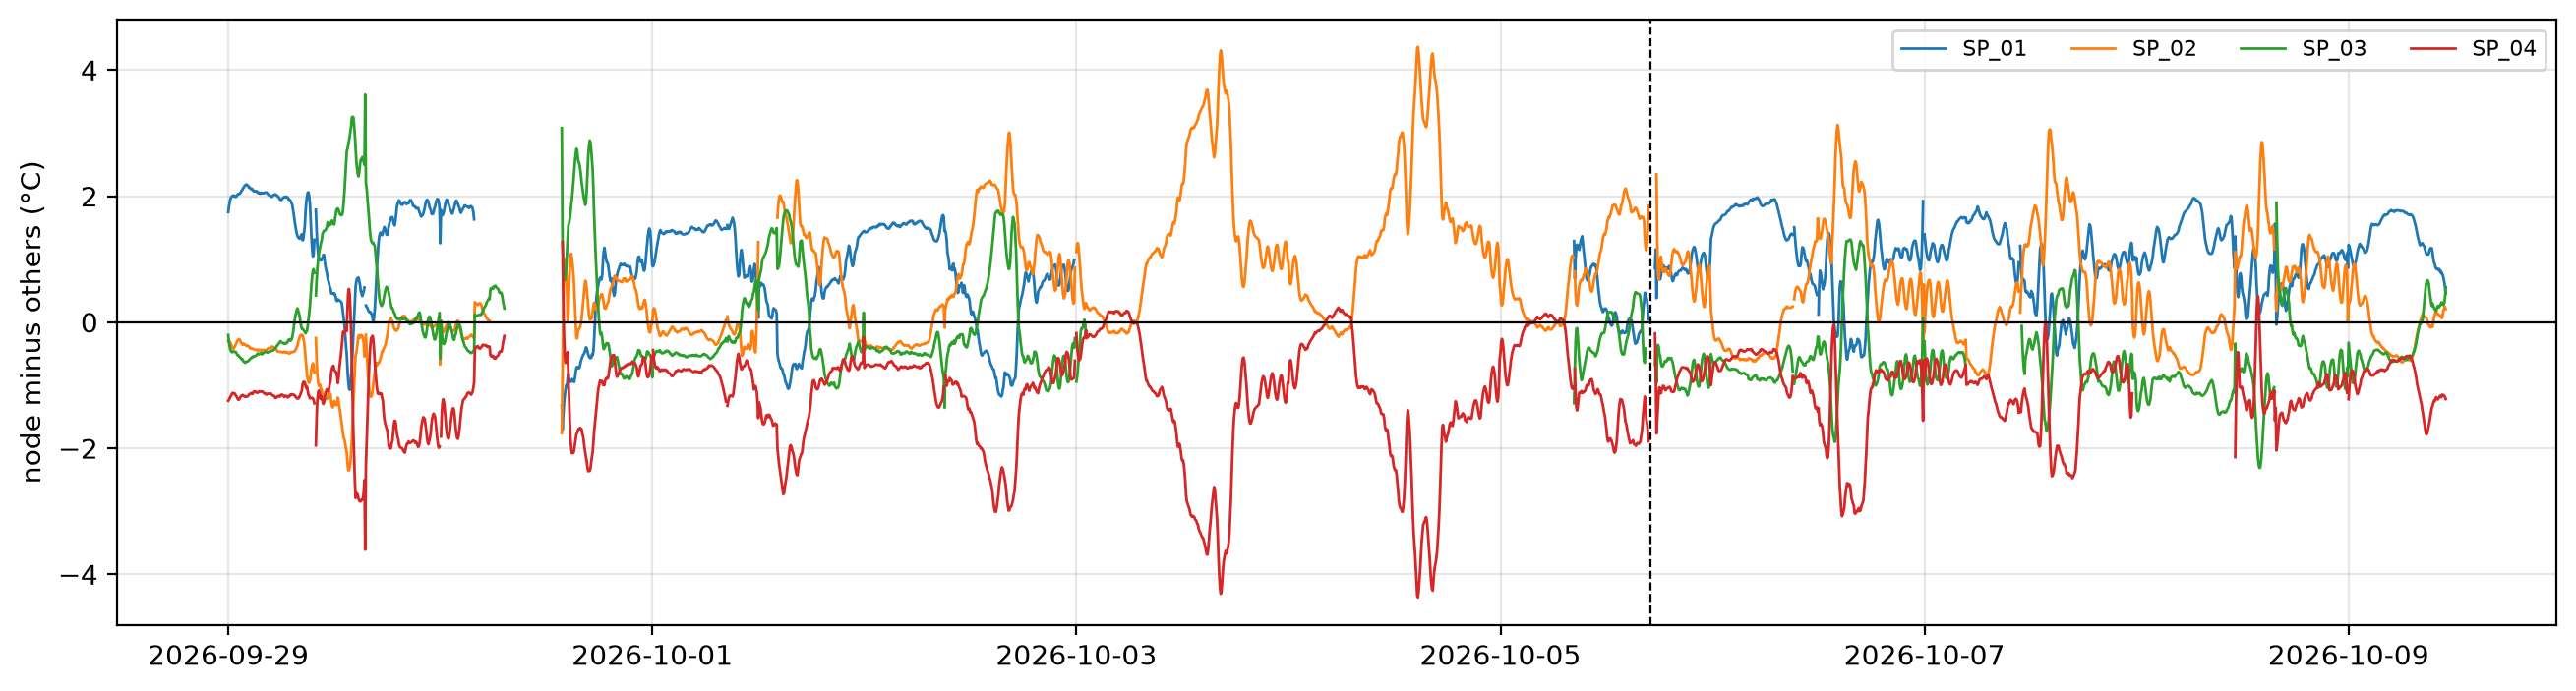

<matplotlib.legend.Legend>

In [ ]:
#| eval: false
tl = node_table(us, 't_smooth')
rel = tl - peers(tl)
r = rel.loc['2026-09-29':]
fig, ax = plt.subplots(figsize=(16, 4))
for n in r: ax.plot(r.index, r[n], lw=1, label=n)
ax.axhline(0, c='k', lw=0.8); ax.axvline(start_new, c='k', ls='--', lw=0.8)
ax.set_ylabel('node minus others (°C)'); ax.grid(alpha=0.3); ax.legend(fontsize=8, ncol=4)

The same difference by time of day, one line per day from 1 October, when the camera scenes had settled after the change on 30 September:

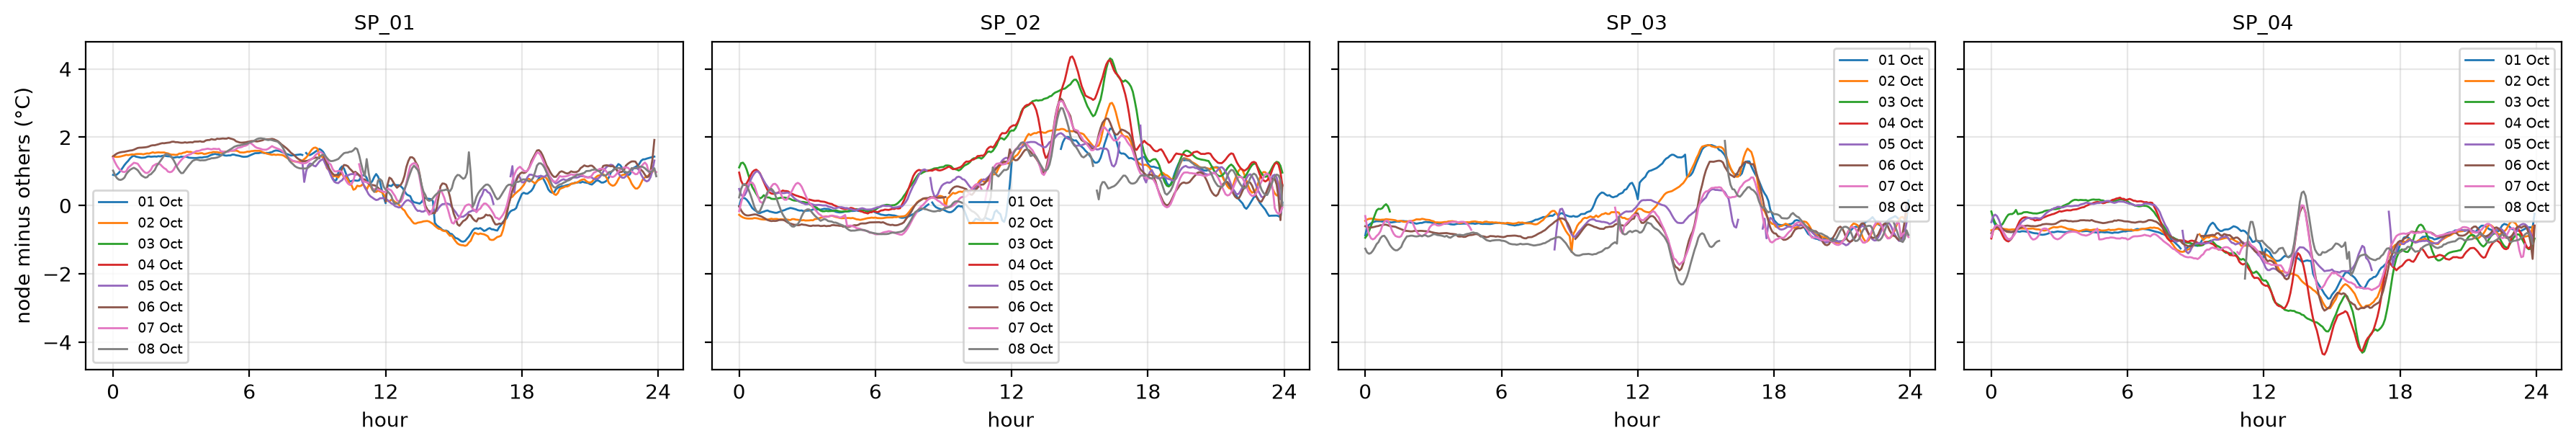

In [ ]:
#| eval: false
long = rel.loc['2026-10-01':'2026-10-08'].stack().rename('rel').reset_index().rename(columns={'t': 'time'})
long = long.assign(day=long.time.dt.normalize(), hour=(long.time - long.time.dt.normalize()).dt.total_seconds() / 3600)
plot_panels(long, 'rel', ylabel='node minus others (°C)')

## Daily indicators

Four numbers per plant and day:

- midday leaf minus air, from 11:00 to 15:00, on the days with Ruuvi readings,
- midday leaf temperature minus the mean of the other plants,
- the daily swing of the smoothed leaf temperature, with the air's swing for reference,
- afternoon (13:00 to 16:00) minus morning (09:00 to 12:00) of the difference to the other plants. Stomata that close as the day goes on make this rise.

In [ ]:
#| eval: false
air = node_table(us, 't_air').mean(axis=1)
h, day = tl.index.hour, tl.index.normalize()
span = (day >= '2026-09-29') & (day < '2026-10-09')
mid, am, pm = (h >= 11) & (h < 15), (h >= 9) & (h < 12), (h >= 13) & (h < 16)
daily = lambda w: w.groupby(lambda t: t.normalize()).mean().rename(index=lambda d: f'{d:%d %b}').round(2)
swing = lambda s: s.max() - s.min() if s.notna().sum() > 250 else np.nan
ind = {'midday leaf - air': daily(tl.sub(air, axis=0)[mid & span]),
       'midday node - others': daily(rel[mid & span]),
       'daily swing': tl[span].groupby(lambda t: t.normalize()).agg(swing).assign(air=air[span].groupby(lambda t: t.normalize()).agg(swing)).rename(index=lambda d: f'{d:%d %b}').round(1),
       'afternoon - morning': (daily(rel[pm & span]) - daily(rel[am & span])).round(2)}
pd.concat(ind, axis=1)

midday leaf - air                   midday node - others                   daily swing                        afternoon - morning                  
node_id             SP_01 SP_02 SP_03 SP_04                SP_01 SP_02 SP_03 SP_04       SP_01 SP_02 SP_03 SP_04  air               SP_01 SP_02 SP_03 SP_04
t                                                                                                                                                          
29 Sep               0.98 -0.16  2.46  0.12                 0.18 -1.35  2.15 -0.97         8.1   8.8  11.5  10.1  9.8               -1.04 -0.10  1.50 -0.38
30 Sep              -1.69 -0.55  0.16 -1.64                -1.09  0.43  1.40 -0.79         NaN   NaN   NaN   NaN  NaN                 NaN   NaN   NaN   NaN
01 Oct               0.11  0.65  0.66 -1.15                 0.21  0.77  0.99 -1.57         7.1  10.1  10.2   7.6  8.5               -1.37  1.92  1.29 -1.20
02 Oct               0.06  1.53  0.41 -1.26                -0.16  1.79  0.30 -1.93         7.3  10.8  10.5   7.5  8.4               -1.51  1.44  1.49 -1.38
03 Oct                NaN   NaN   NaN   NaN                  NaN  2.79   NaN -2.79         NaN  10.7   NaN   7.4  NaN                 NaN  1.76   NaN -1.76
04 Oct                NaN   NaN   NaN   NaN                  NaN  2.62   NaN -2.62         NaN  11.9   NaN   9.7  NaN                 NaN  1.55   NaN -1.55
05 Oct               0.88  2.09  0.74 -0.36                 0.06  1.67 -0.13 -1.60         NaN   9.4   NaN   6.7  NaN               -0.85  0.98  0.46 -0.60
06 Oct               1.46  2.30  0.52 -0.16                 0.57  1.70 -0.67 -1.58         8.3  11.6   9.8   9.2  8.6               -0.73  1.29  0.43 -1.01
07 Oct               1.20  2.20  0.41 -0.21                 0.40  1.74 -0.66 -1.48         8.4  10.4   NaN   9.5  8.6               -0.73  1.42 -0.02 -0.38
08 Oct               0.95  1.70 -0.28 -0.17                 0.54  1.54 -1.10 -1.01         8.7  11.3   8.3   NaN  8.9               -0.60  1.39 -0.05 -0.04

## Daily fits

`daily_fits` fits each plant's smoothed leaf temperature against a reference, separately for each day and for each night. Three references:

- air temperature: a well-transpiring leaf warms more slowly than the air by day, with a slope below 1,
- the mean of the other plants, from `peers`: a plant that closes its stomata warms faster than the others, and its slope rises,
- VPD, for leaf minus air: a transpiring leaf cools further below the air as VPD rises, which gives a negative slope. The slope moves towards 0, or above, when transpiration stops.

The fits start on 30 September, after the scene change. On 7 October `SP_03` and on 8 October `SP_04` restarted in the morning, so those day fits cover only the afternoon:

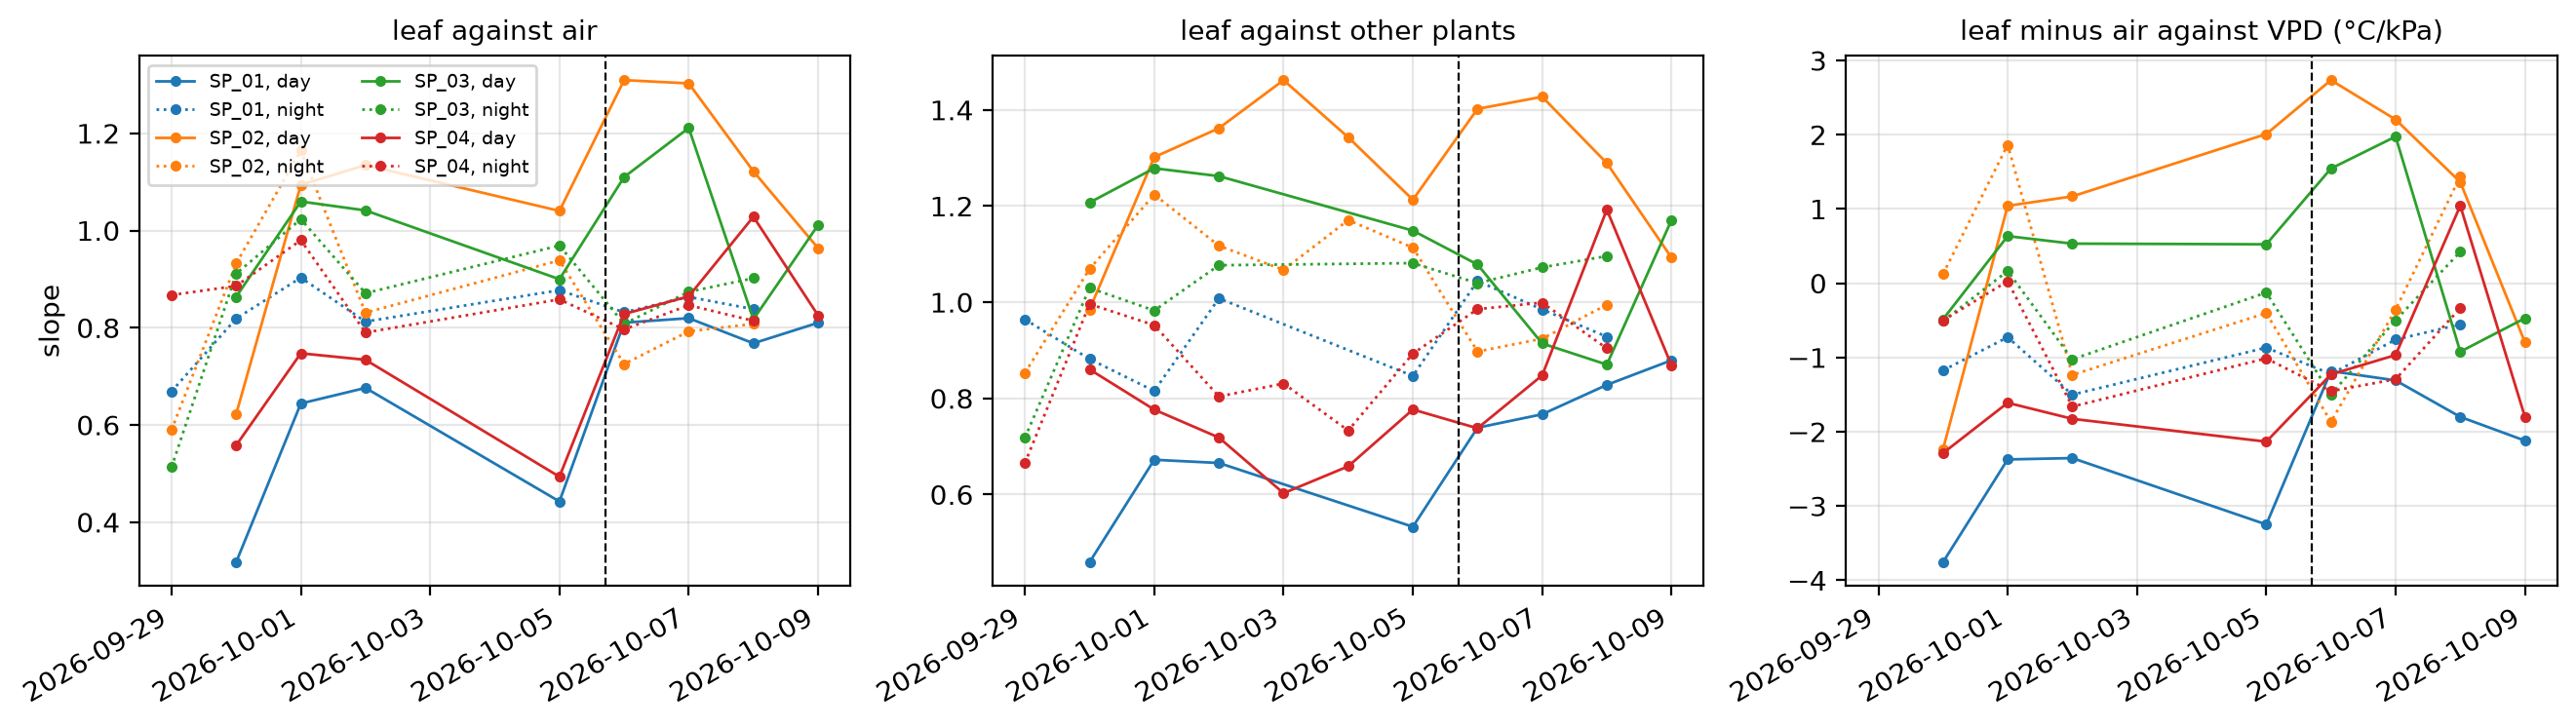

In [ ]:
#| eval: false
w = tl.loc['2026-09-30':]
vp = node_table(us, 'vpd').mean(axis=1)
fits = {'leaf against air': daily_fits(w, air), 'leaf against other plants': daily_fits(w, peers(w)),
        'leaf minus air against VPD (°C/kPa)': daily_fits(node_table(us, 'dt_smooth').loc['2026-09-30':], vp)}
fig, axs = plt.subplots(1, 3, figsize=(16, 4), sharex=True)
for ax, (k, f) in zip(axs, fits.items()):
    for (n, reg), g in f.groupby(['node_id', 'regime']):
        ax.plot(g.day, g.slope, marker='o', ms=3, lw=1, ls='-' if reg == 'day' else ':', c=f'C{int(n[-1]) - 1}', label=f'{n}, {reg}')
    ax.axvline(start_new, c='k', ls='--', lw=0.8); ax.set_title(k, fontsize=10); ax.grid(alpha=0.3)
axs[0].set_ylabel('slope'); axs[0].legend(fontsize=7, ncol=2); fig.autofmt_xdate()

The day slopes as a table:


In [ ]:
#| eval: false
pd.concat({k: f[f.regime == 'day'].pivot(index='day', columns='node_id', values='slope') for k, f in fits.items()}, axis=1).rename(index=lambda d: f'{d:%d %b}').round(2)

<ipython-input-7-bacf4ad6a93a>:2: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  pd.concat({k: f[f.regime == 'day'].pivot(index='day', columns='node_id', values='slope') for k, f in fits.items()}, axis=1).rename(index=lambda d: f'{d:%d %b}').round(2)


leaf against air                   leaf against other plants                   leaf minus air against VPD (°C/kPa)                  
node_id            SP_01 SP_02 SP_03 SP_04                     SP_01 SP_02 SP_03 SP_04                               SP_01 SP_02 SP_03 SP_04
day                                                                                                                                         
30 Sep              0.32  0.62  0.86  0.56                      0.46  0.98  1.21  0.86                               -3.76 -2.24 -0.48 -2.29
01 Oct              0.64  1.09  1.06  0.75                      0.67  1.30  1.28  0.78                               -2.37  1.04  0.63 -1.61
02 Oct              0.68  1.13  1.04  0.73                      0.67  1.36  1.26  0.72                               -2.36  1.17  0.53 -1.83
03 Oct               NaN   NaN   NaN   NaN                       NaN  1.46   NaN  0.60                                 NaN   NaN   NaN   NaN
04 Oct               NaN   NaN   NaN   NaN                       NaN  1.34   NaN  0.66                                 NaN   NaN   NaN   NaN
05 Oct              0.44  1.04  0.90  0.49                      0.53  1.21  1.15  0.78                               -3.25  2.01  0.52 -2.13
06 Oct              0.81  1.31  1.11  0.83                      0.74  1.40  1.08  0.74                               -1.18  2.73  1.54 -1.23
07 Oct              0.82  1.30  1.21  0.86                      0.77  1.43  0.91  0.85                               -1.31  2.20  1.97 -0.97
08 Oct              0.77  1.12  0.82  1.03                      0.83  1.29  0.87  1.19                               -1.80  1.36 -0.92  1.04
09 Oct              0.81  0.96  1.01  0.83                      0.88  1.09  1.17  0.87                               -2.12 -0.79 -0.47 -1.80

## Soil moisture

Soil moisture is the closest thing to an answer key, so it comes last. All four soil sensors work in the new period. Their readings are not calibrated against each other, so the trend of each sensor matters more than its level:

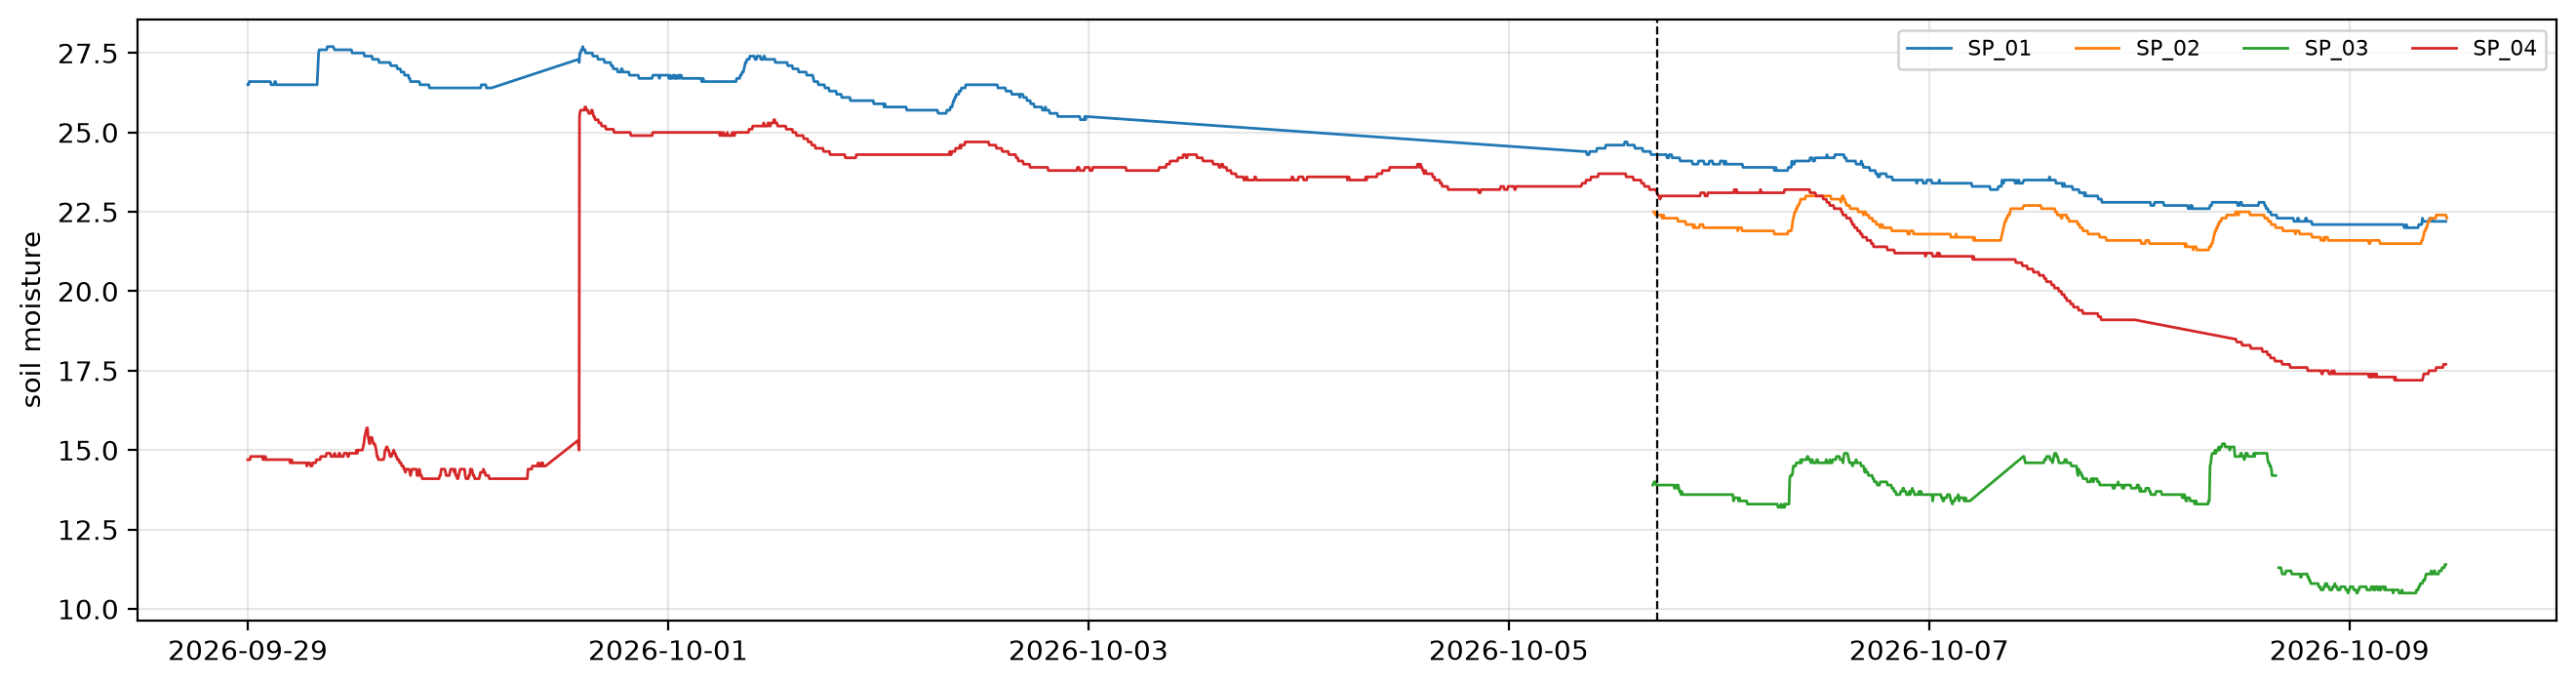

<matplotlib.legend.Legend>

In [ ]:
#| eval: false
s = mdf[mdf.time >= '2026-09-29']
fig, ax = plt.subplots(figsize=(16, 4))
for n, g in s.groupby('node_id'): ax.plot(g.time, g.soil_moisture, lw=1, label=n)
ax.axvline(start_new, c='k', ls='--', lw=0.8); ax.set_ylabel('soil moisture'); ax.grid(alpha=0.3); ax.legend(fontsize=8, ncol=4)

A plant draws water from the soil by day and almost none at night. The change in soil moisture from sunrise to sunset, and from sunset to the next sunrise, measures that uptake. Each value is the median of the half hour that contains the sun event:

In [ ]:
#| eval: false
st = sun_times(pd.date_range('2026-09-29', '2026-10-09'))
sm = mdf.set_index('time').groupby('node_id').soil_moisture.resample('30min').median().unstack(0)
at = lambda t: sm.reindex(t.dt.floor('30min').to_numpy()).set_axis(t.index)
rise, sset = at(st.sunrise), at(st.sunset)
uptake = pd.concat({'sunrise to sunset': sset - rise, 'sunset to next sunrise': rise.shift(-1) - sset}, axis=1).iloc[:-1]
uptake.rename(index=lambda d: f'{d:%d %b}').round(2)

sunrise to sunset                   sunset to next sunrise                  
node_id             SP_01 SP_02 SP_03 SP_04                  SP_01 SP_02 SP_03 SP_04
day                                                                                 
29 Sep               0.10   NaN   NaN  -0.2                    NaN   NaN   NaN  -0.3
30 Sep                NaN   NaN   NaN  10.9                  -0.30   NaN   NaN  -0.1
01 Oct              -0.30   NaN   NaN  -0.6                  -0.60   NaN   NaN   0.0
02 Oct               0.05   NaN   NaN  -0.4                    NaN   NaN   NaN  -0.1
03 Oct                NaN   NaN   NaN  -0.3                    NaN   NaN   NaN   0.0
04 Oct                NaN   NaN   NaN  -0.3                    NaN   NaN   NaN   0.1
05 Oct                NaN   NaN   NaN  -0.3                  -0.45  -0.5  -0.7   0.1
06 Oct              -0.15   0.3   0.7  -1.7                  -0.45  -0.5   NaN  -0.4
07 Oct              -0.20   0.2   NaN  -1.7                  -0.40  -0.5  -0.7   NaN
08 Oct              -0.40   0.6  -2.2   NaN                  -0.20  -0.4  -0.6  -0.4

`SP_02` and `SP_03` gain moisture by day. The rise happens between about 08:00 and 09:00, and stops while the soil temperature keeps rising until noon. It is a step, most likely a morning watering, not a temperature effect on the sensor. The change from 06:30 to 09:30 measures it:

In [ ]:
#| eval: false
mean_at = lambda a, b: sm.between_time(a, b).groupby(lambda t: t.normalize()).mean()
step = mean_at('09:30', '09:59') - mean_at('06:30', '06:59')
step.loc['2026-09-29':].rename(index=lambda d: f'{d:%d %b}').round(2)

node_id,SP_01,SP_02,SP_03,SP_04
time,,,,
29 Sep,1.2,NaN,NaN,0.2
30 Sep,NaN,NaN,NaN,0.4
01 Oct,0.8,NaN,NaN,0.3
02 Oct,0.7,NaN,NaN,0.3
03 Oct,NaN,NaN,NaN,0.3
04 Oct,NaN,NaN,NaN,0.3
05 Oct,NaN,NaN,NaN,0.3
06 Oct,0.3,1.1,1.45,0.1
07 Oct,0.2,1.0,NaN,0.0


## Logbook check

Scene changes in the new period would confound the thermal signals:

In [ ]:
#| eval: false
check_logbook(mdf, read_deployments('../../../logbook/deployments.csv'))

,check,node_id,detail
0,scene change,SP_01,"25 Sep to 28 Sep: r = 0.38, inside d01"
1,scene change,SP_01,"29 Sep to 30 Sep: r = 0.22, inside d01"
2,scene change,SP_01,"02 Oct to 05 Oct: r = 0.09, inside d01"
3,scene change,SP_02,"23 Sep to 24 Sep: r = -0.02, inside d02"
4,scene change,SP_02,"29 Sep to 30 Sep: r = 0.45, inside d02"
5,scene change,SP_02,"30 Sep to 01 Oct: r = 0.38, inside d02"
6,scene change,SP_03,"24 Sep to 26 Sep: r = -0.00, inside d03"
7,scene change,SP_03,"26 Sep to 29 Sep: r = 0.28, inside d03"
8,scene change,SP_03,"29 Sep to 30 Sep: r = 0.19, inside d03"
9,scene change,SP_04,"29 Sep to 30 Sep: r = 0.03, inside d04"


## Diagnosis

`SP_04` is the most likely stressed plant. The thermal signals agree:

- Its midday leaf minus air rose from about -1.2 °C on 1 and 2 October to about -0.2 °C on 6 to 8 October.
- Its midday difference to the other plants rose from about -1.9 °C on 2 October to -1.0 °C on 8 October.
- Its daily swing grew from 7.4 to 7.6 °C on 1 to 3 October to 9.2 to 9.5 °C on 6 and 7 October, while the air's swing stayed at 8.4 to 8.6 °C.
- Its afternoon warming relative to the morning was -1.2 to -1.8 °C on 1 to 4 October. It rose from 6 October onwards, to -1.0, -0.4 and 0.0 °C on 6, 7 and 8 October.
- Its leaf minus air cooled by 1.6 to 1.8 °C per kPa of VPD on 1 and 2 October. That fell to 1.2 and 1.0 °C per kPa on 6 and 7 October, and on 8 October its leaves warmed by 1.0 °C per kPa instead.
- Its day slope against the other plants was 0.60 to 0.78 from 1 to 6 October. It rose to 0.85 on 7 October and 1.19 on 8 October.

The 8 October fits for `SP_04` cover only the afternoon, after the restart at 10:46. The day slopes against air rose for all four plants on 6 and 7 October, which points to a shared cause such as the weather. Midday VPD stayed between 1.6 and 1.8 kPa.

The soil agrees. Up to 5 October, `SP_04` gained about 0.3 every morning between 06:30 and 09:30. That step was 0.1 and 0.0 on 6 and 7 October, and back at 0.3 on 9 October. Its soil lost 1.7 between sunrise and sunset on 6 and 7 October, against 0.3 to 0.6 before. Its moisture fell from 23.3 on 5 October to 17.3 on 9 October. This looks like watering stopped after 5 October and restarted on the morning of 9 October.

`SP_01` also warmed relative to air, by about 1 °C, but its camera scene changed between 2 and 5 October, which makes its baseline unreliable. Its response to VPD weakened on 6 and 7 October and recovered on 8 and 9 October. `SP_03` moved the other way: its midday temperature fell relative to the other plants. Its soil reads lowest, and lost about 3.7 within a few hours on the afternoon of 8 October. That is too fast for uptake by the plant, and the cause is unknown.

The leaf minus air of `SP_02` and `SP_03` rises with VPD. A transpiring leaf does not do that. Their unmasked images may be dominated by surfaces other than leaves.